In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.datasets import make_classification


In [2]:
X,y= make_classification(n_features=5,n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.975605,-1.497421,1.006418,1.217937,0.152362,1
1,2.449036,-2.946073,2.020737,-2.361226,2.442201,0
2,-0.601773,2.273957,-0.232620,-2.166215,-1.254952,1
3,-1.334844,-0.842833,-0.282425,-1.036278,0.742934,0
4,-2.492552,-5.348237,2.410960,4.687497,1.102892,1


In [4]:
# fucntion for row sampling

def sample_rows(df, percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling 

def sample_features(df, percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
    new_df = df[cols].copy()
    new_df.loc[:, 'target'] = df['target'].to_numpy()
    return new_df
    

In [6]:
# function for combined sampling 

def combined_sampling(df,row_percent, col_percent):
    new_df = sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [7]:

df1 = combined_sampling(df,0.5,0.5)

In [8]:
df2 = combined_sampling(df,0.5,0.5)

In [9]:

df3 = combined_sampling(df,0.5,0.5)

In [10]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col1', 'target'], dtype='object')
Index(['col3', 'col2', 'target'], dtype='object')
Index(['col2', 'col1', 'target'], dtype='object')


In [11]:
df3

,col2,col1,target
44,-2.271202,2.778882,0
52,1.402908,1.832570,0
3,-0.842833,-1.334844,0
1,-2.946073,2.449036,0
7,-1.737828,-1.270460,1
8,-0.895580,1.916349,0
36,-1.141906,2.389110,0
65,-1.805614,1.179455,0
58,-0.832454,-1.586773,1
22,-0.438048,0.323113,0


In [12]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [13]:

clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [14]:


from sklearn.tree import plot_tree

[Text(0.5416666666666666, 0.9166666666666666, 'x[1] <= -0.526\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.25, 0.75, 'x[0] <= -1.336\ngini = 0.227\nsamples = 23\nvalue = [3, 20]'),
 Text(0.3958333333333333, 0.8333333333333333, 'True  '),
 Text(0.16666666666666666, 0.5833333333333334, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3333333333333333, 0.5833333333333334, 'x[0] <= 1.823\ngini = 0.165\nsamples = 22\nvalue = [2, 20]'),
 Text(0.16666666666666666, 0.4166666666666667, 'x[1] <= -1.405\ngini = 0.1\nsamples = 19\nvalue = [1, 18]'),
 Text(0.08333333333333333, 0.25, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.25, 0.25, 'x[1] <= -1.333\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.16666666666666666, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3333333333333333, 0.08333333333333333, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.5, 0.4166666666666667, 'x[1] <= -1.935\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(

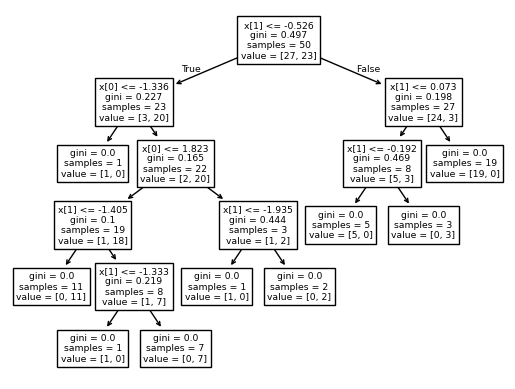

In [15]:
plot_tree(clf1)

[Text(0.35, 0.9285714285714286, 'x[1] <= -2.618\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.1, 0.7857142857142857, 'x[1] <= -2.973\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.22499999999999998, 0.8571428571428572, 'True  '),
 Text(0.05, 0.6428571428571429, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.15, 0.6428571428571429, 'x[0] <= 0.905\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.7857142857142857, 'x[0] <= 1.046\ngini = 0.459\nsamples = 42\nvalue = [27.0, 15.0]'),
 Text(0.475, 0.8571428571428572, '  False'),
 Text(0.4, 0.6428571428571429, 'x[1] <= -0.396\ngini = 0.496\nsamples = 22\nvalue = [10, 12]'),
 Text(0.3, 0.5, 'x[0] <= -0.554\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.25, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.35, 0.35714285714285715, 'gini = 0.0\nsamples = 8\nvalue

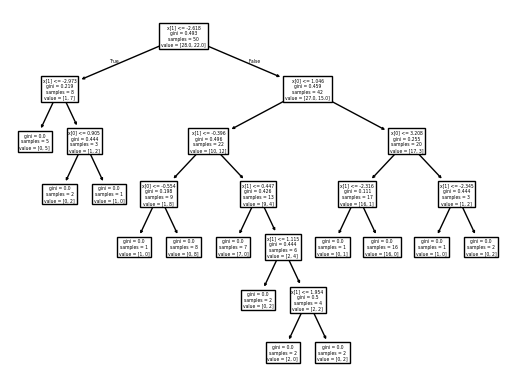

In [16]:
plot_tree(clf2)

[Text(0.5714285714285714, 0.9375, 'x[1] <= -0.57\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.2857142857142857, 0.8125, 'x[0] <= -1.196\ngini = 0.384\nsamples = 27\nvalue = [7, 20]'),
 Text(0.42857142857142855, 0.875, 'True  '),
 Text(0.21428571428571427, 0.6875, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.35714285714285715, 0.6875, 'x[0] <= -0.838\ngini = 0.492\nsamples = 16\nvalue = [7, 9]'),
 Text(0.2857142857142857, 0.5625, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.42857142857142855, 0.5625, 'x[0] <= 1.041\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.35714285714285715, 0.4375, 'x[1] <= -0.987\ngini = 0.375\nsamples = 12\nvalue = [3, 9]'),
 Text(0.21428571428571427, 0.3125, 'x[1] <= -1.789\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.14285714285714285, 0.1875, 'x[0] <= -0.263\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.07142857142857142, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.21428571428571427, 0.062

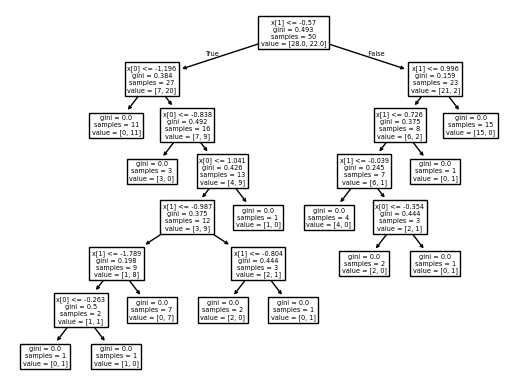

In [17]:
plot_tree(clf3)

In [18]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))
     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [19]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))
     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [20]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))
     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])